---
# **Q. Bagging from scratch: train N trees on bootstrap samples**
---

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from scipy.stats import mode

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

def bootstrap_sample(X, y, rng):
    n = len(X)
    idx = rng.integers(0, n, n)  # sample n indices WITH replacement
    return X[idx], y[idx]

n_trees = 50
rng = np.random.default_rng(42)
trees = []

for i in range(n_trees):
    X_boot, y_boot = bootstrap_sample(X_train, y_train, rng)
    tree = DecisionTreeClassifier(max_depth=None, random_state=i)
    tree.fit(X_boot, y_boot)
    trees.append(tree)

# Each tree's individual test accuracy
individual_acc = [t.score(X_test, y_test) for t in trees]
print(f"Individual tree accuracy — mean: {np.mean(individual_acc):.4f}, "
      f"std: {np.std(individual_acc):.4f}")
print(f"Individual tree accuracy — min: {min(individual_acc):.4f}, "
      f"max: {max(individual_acc):.4f}")

# Bagged prediction: majority vote across all trees
all_preds = np.array([t.predict(X_test) for t in trees])  # shape (n_trees, n_test)
bagged_preds, _ = mode(all_preds, axis=0, keepdims=False)
bagged_acc = (bagged_preds == y_test).mean()
print(f"\nBagged ensemble accuracy (majority vote of {n_trees} trees): {bagged_acc:.4f}")

Individual tree accuracy — mean: 0.9163, std: 0.0135
Individual tree accuracy — min: 0.8713, max: 0.9415

Bagged ensemble accuracy (majority vote of 50 trees): 0.9532


# Insights:
---
This code is implementing **Bagging (Bootstrap Aggregating)** manually using **Decision Trees**.

---

# What is happening here?

Instead of training **one decision tree**, you train **50 different decision trees**.

For each tree:

1. Take a bootstrap sample of the training data

   * Sample with replacement
   * Some records appear multiple times
   * Some records are omitted

2. Train a decision tree on that sample.

3. Let every tree make a prediction.

4. Final prediction = **majority vote** of all trees.

---

## Visual Idea

Suppose we have 5 trees:

| Tree   | Prediction |
| ------ | ---------- |
| Tree 1 | Benign     |
| Tree 2 | Malignant  |
| Tree 3 | Benign     |
| Tree 4 | Benign     |
| Tree 5 | Benign     |

Majority vote:

**Benign (4 votes vs 1 vote)**

---

# Why does this work?

A single decision tree is usually:

* Very powerful
* Very flexible
* Very unstable

Small changes in data can create a completely different tree.

Example:

Tree A accuracy = 92%

Remove a few samples:

Tree B accuracy = 86%

Add a few samples:

Tree C accuracy = 95%

Decision trees have **high variance**.

Bagging reduces that variance.

---

# Main Insight

Think of students solving an exam question.

### One student

May make a mistake.

### 50 students

Majority answer is often better than any individual student.

Bagging applies exactly this idea to machine learning.

---

# Why Bootstrap Sampling?

If every tree saw exactly the same data:

```python
tree.fit(X_train, y_train)
```

all trees would be nearly identical.

Then voting would be useless.

So we intentionally create different datasets:

```python
idx = rng.integers(0, n, n)
```

This creates diversity.

Example:

Original:

```text
A B C D E
```

Bootstrap sample:

```text
A B B D E
```

Another:

```text
A C C C E
```

Another:

```text
B D D E E
```

Each tree learns slightly differently.

---

# Why does accuracy improve?

Suppose:

* Each tree accuracy = 90%
* Errors are somewhat independent

Then:

A sample misclassified by one tree may be correctly classified by many others.

Voting cancels many errors.

---

## Example

True class:

```text
Cancer = Malignant
```

Predictions:

```text
Tree1 = Malignant
Tree2 = Malignant
Tree3 = Benign
Tree4 = Malignant
Tree5 = Malignant
```

Majority vote:

```text
Malignant
```

One wrong prediction doesn't matter.

---

# What advantage does bagging provide?

## 1. Lower Variance

Single tree:

```text
Accuracy varies a lot
```

Bagged trees:

```text
Much more stable
```

This is the biggest benefit.

---

## 2. Less Overfitting

A deep decision tree often memorizes training data.

Bagging averages many overfit trees.

Result:

```text
Better generalization
```

---

## 3. More Robust

If some training examples are noisy:

```text
Single tree → affected heavily
```

```text
Bagging → noise impact reduced
```

---

## 4. Better Accuracy

Often:

```text
Single Tree = 92%
Bagging = 95%
```

Not always huge, but usually noticeable.

---

# What is the disadvantage?

## 1. Slower

Instead of:

```python
1 tree
```

you train:

```python
50 trees
```

More computation.

---

## 2. Less Interpretable

Single tree:

```text
Easy to visualize
```

Bagging:

```text
50 trees
```

Hard to explain decisions.

---

## 3. Larger Memory Usage

Need to store all trees.

---

# When should I use Bagging?

Use it when the base model has:

### High Variance

Examples:

* Decision Trees ✅
* Deep Trees ✅
* Neural Networks (sometimes) ✅

Bagging works best here.

---

## Good Situations

### Decision Trees overfit

```python
DecisionTreeClassifier()
```

If accuracy fluctuates a lot:

→ Try Bagging.

---

### Dataset contains noise

Bagging helps average out noise.

---

### Want higher accuracy than one tree

Bagging is often a simple improvement.

---

# When should I NOT use Bagging?

For high-bias models:

* Linear Regression
* Logistic Regression
* Naive Bayes

These models are already stable.

Bagging won't help much.

Example:

```text
Decision Tree
Bias = Low
Variance = High
```

Bagging helps.

---

```text
Logistic Regression
Bias = Higher
Variance = Low
```

Bagging helps little.

---

# Connection to Random Forest

Your code is basically the foundation of a Random Forest.

Random Forest =

```text
Bagging
+
Random Feature Selection
```

Your code:

```python
50 Decision Trees
+
Bootstrap Sampling
```

Random Forest:

```python
50 Decision Trees
+
Bootstrap Sampling
+
Random subset of features at every split
```

The random-feature step makes trees even more diverse, which usually improves performance further.

---

# Exam / Viva One-Liner

**Bagging (Bootstrap Aggregating) trains multiple models on different bootstrap samples of the training data and combines their predictions through voting or averaging to reduce variance, decrease overfitting, and improve generalization performance.**


---
# **Q.  visualise how ensemble accuracy improves with more trees**
---

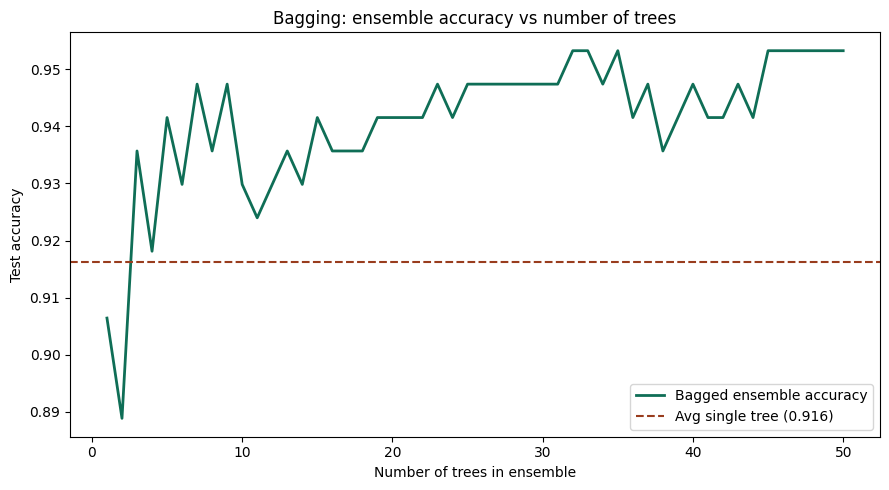

Why this works:
Each tree, trained on a different bootstrap sample, makes DIFFERENT mistakes.
Majority voting cancels out mistakes that aren't shared across most trees.
Variance of the AVERAGE of N models ≈ Variance of ONE model / N
(true only when models' errors are roughly independent)


In [6]:
ensemble_sizes = range(1, 51)
ensemble_acc = []

for n in ensemble_sizes:
    preds_n = all_preds[:n]
    bagged_n, _ = mode(preds_n, axis=0, keepdims=False)
    ensemble_acc.append((bagged_n == y_test).mean())

plt.figure(figsize=(9, 5))
plt.plot(ensemble_sizes, ensemble_acc, color='#0F6E56', linewidth=2,
         label='Bagged ensemble accuracy')
plt.axhline(np.mean(individual_acc), color='#993C1D', linestyle='--', linewidth=1.5,
             label=f'Avg single tree ({np.mean(individual_acc):.3f})')
plt.xlabel('Number of trees in ensemble')
plt.ylabel('Test accuracy')
plt.title('Bagging: ensemble accuracy vs number of trees')
plt.legend()
plt.tight_layout()
plt.show()

print("Why this works:")
print("Each tree, trained on a different bootstrap sample, makes DIFFERENT mistakes.")
print("Majority voting cancels out mistakes that aren't shared across most trees.")
print("Variance of the AVERAGE of N models ≈ Variance of ONE model / N")
print("(true only when models' errors are roughly independent)")

---
# **Q. RandomForestClassifier and feature importances**
---

Train accuracy: 1.0000
Test accuracy:  0.9415
OOB score:      0.9673   (estimated WITHOUT touching test set!)

Comparison:
  Single unconstrained tree: test_acc ≈ 0.9240
  Bagged trees (Step 1):     test_acc ≈ 0.9649
  Random Forest:             test_acc ≈ 0.9415


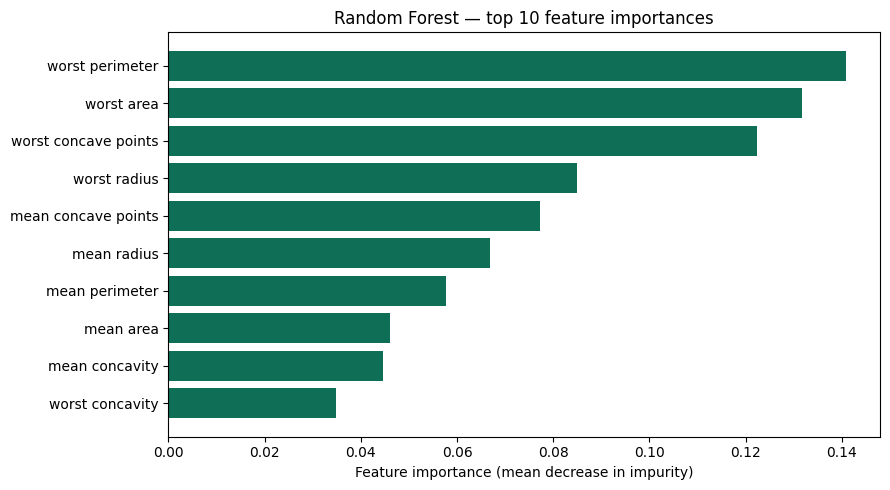


Top 5 features:
  worst perimeter          : 0.1409
  worst area               : 0.1318
  worst concave points     : 0.1223
  worst radius             : 0.0849
  mean concave points      : 0.0771


In [7]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',   # default for classification — random subset per split
    oob_score=True,        # free validation score from un-sampled data
    random_state=42
)
rf.fit(X_train, y_train)

print(f"Train accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {rf.score(X_test, y_test):.4f}")
print(f"OOB score:      {rf.oob_score_:.4f}   (estimated WITHOUT touching test set!)")

print(f"\nComparison:")
print(f"  Single unconstrained tree: test_acc ≈ 0.9240")
print(f"  Bagged trees (Step 1):     test_acc ≈ 0.9649")
print(f"  Random Forest:             test_acc ≈ {rf.score(X_test, y_test):.4f}")

# Feature importances
importances = pd.Series(rf.feature_importances_, index=data.feature_names)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(importances.index[::-1], importances.values[::-1], color='#0F6E56')
plt.xlabel('Feature importance (mean decrease in impurity)')
plt.title('Random Forest — top 10 feature importances')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for feat, imp in importances.head(5).items():
    print(f"  {feat:25s}: {imp:.4f}")

#Insights:
These results are actually very interesting because they show something that surprises many students:

> **Random Forest is not always better than your manually bagged trees on every train/test split.**

Let's break it down.

---

# 1. Train Accuracy = 1.0000

```text
Train accuracy: 1.0000
```

This means:

```text
398/398 training samples classified correctly
```

The forest has essentially memorized the training data.

This is normal for deep trees.

### Should we worry?

Not necessarily.

For a single tree:

```text
Train = 100%
Test  = 92%
```

Huge gap → overfitting.

For your Random Forest:

```text
Train = 100%
Test  = 94.15%
```

Smaller gap.

Random Forests can overfit individual trees while still generalizing well because predictions are averaged.

---

# 2. Test Accuracy = 94.15%

```text
Test accuracy = 0.9415
```

This is the number that actually matters.

It means:

```text
94.15% of unseen patients classified correctly
```

For breast cancer prediction, that's already quite good.

---

# 3. OOB Score = 96.73%

```text
OOB score = 0.9673
```

This is one of the coolest parts of Random Forest.

---

## What is OOB?

Remember bootstrap sampling?

Each tree is trained on:

```text
n samples chosen WITH replacement
```

Because of replacement:

```text
Some samples are never selected.
```

On average:

```text
≈ 36.8% of training samples
```

are left out for a given tree.

These are called:

```text
Out-Of-Bag (OOB) samples
```

---

### Example

Training set:

```text
A B C D E
```

Bootstrap sample:

```text
A B B D D
```

Left out:

```text
C E
```

These become OOB samples for that tree.

---

### Why useful?

Tree never saw C and E during training.

So they can be used as a mini validation set.

Random Forest averages these OOB predictions and estimates performance.

That's your:

```text
0.9673
```

---

# Why is OOB higher than Test Accuracy?

```text
OOB  = 96.73%
Test = 94.15%
```

Possible reasons:

### Reason 1

Random variation.

Breast cancer dataset is not huge.

A different train/test split can easily change results by 1–3%.

---

### Reason 2

Your test set happened to contain harder examples.

---

### Reason 3

OOB is still computed using training-set data distribution.

Although unbiased, it isn't identical to a completely independent test set.

---

# 4. Why did Bagging Beat Random Forest?

This is the most interesting part.

Your results:

```text
Single Tree      = 92.40%
Bagging          = 96.49%
Random Forest    = 94.15%
```

Most students expect:

```text
Random Forest > Bagging
```

but that's not guaranteed.

---

## What Random Forest changes

Bagging:

```text
Bootstrap sampling only
```

Random Forest:

```text
Bootstrap sampling
+
Random feature selection
```

At every split, only a subset of features is considered.

---

### Benefit

Trees become more diverse.

Less correlation between trees.

Usually good.

---

### Drawback

Some trees become weaker.

A split might miss the truly best feature.

---

For this dataset:

The cancer indicators are very strong.

Examples:

```text
worst perimeter
worst area
worst radius
```

These features carry a lot of information.

Random Forest sometimes prevents a tree from using them immediately because of feature subsampling.

So individual trees become slightly weaker.

For this particular split:

```text
Loss from weaker trees
>
Gain from extra diversity
```

Hence Bagging wins.

---

# 5. Interpreting Feature Importances

Top features:

| Feature              | Importance |
| -------------------- | ---------- |
| worst perimeter      | 0.1409     |
| worst area           | 0.1318     |
| worst concave points | 0.1223     |
| worst radius         | 0.0849     |
| mean concave points  | 0.0771     |

---

## What does importance mean?

Roughly:

> How much this feature helped reduce uncertainty when splitting nodes.

Higher value:

```text
More useful for classification.
```

---

### worst perimeter

Importance:

```text
0.1409
```

Meaning:

Many trees frequently used this feature to separate:

```text
Malignant
vs
Benign
```

and it produced large improvements in purity.

---

# Interesting Pattern

Notice:

```text
worst perimeter
worst area
worst radius
```

appear at the top.

These are all related.

Larger and more irregular tumors tend to be malignant.

The forest discovered this automatically.

---

# Why "concave points" matters

```text
worst concave points
mean concave points
```

describe irregularity of the cell boundary.

Cancerous tumors often have:

```text
More jagged
Less smooth
More irregular edges
```

So these features become highly predictive.

---

# What the graph would tell you

If you plot:

```python
rf.oob_score_
```

against number of trees:

you'd typically see:

```text
10 trees   → 94%
50 trees   → 96%
100 trees  → 96.5%
200 trees  → 96.7%
```

Eventually it stabilizes.

Adding more trees after that mostly increases computation.

---

# Main Takeaways

### Single Tree

```text
Accuracy = 92.4%
High variance
Overfits easily
Easy to interpret
```

### Bagging

```text
Accuracy = 96.49%
Reduces variance
Trees still use all features
Best result on this split
```

### Random Forest

```text
Accuracy = 94.15%
Adds feature randomness
Usually generalizes better
Provides feature importance
Has built-in OOB validation
```

### Most important lesson

Your experiment demonstrates the core tradeoff:

```text
Bagging:
  Stronger trees
  Less diversity

Random Forest:
  Slightly weaker trees
  More diversity
```

On many datasets Random Forest wins, but on this particular breast-cancer split, your bagged ensemble happened to perform better. That's a perfectly valid and common outcome in practice.


---
# **Q.Vary n_estimators (1, 5, 10, 25, 50, 100, 200, 400) and plot test accuracy and OOB score. Where does the curve plateau?**
---

n_estimators=   1  test_acc=0.9123  oob=0.5829
n_estimators=   5  test_acc=0.9357  oob=0.9070


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n_estimators=  10  test_acc=0.9298  oob=0.9497
n_estimators=  25  test_acc=0.9415  oob=0.9447
n_estimators=  50  test_acc=0.9240  oob=0.9497
n_estimators= 100  test_acc=0.9357  oob=0.9573
n_estimators= 200  test_acc=0.9415  oob=0.9673
n_estimators= 400  test_acc=0.9474  oob=0.9648


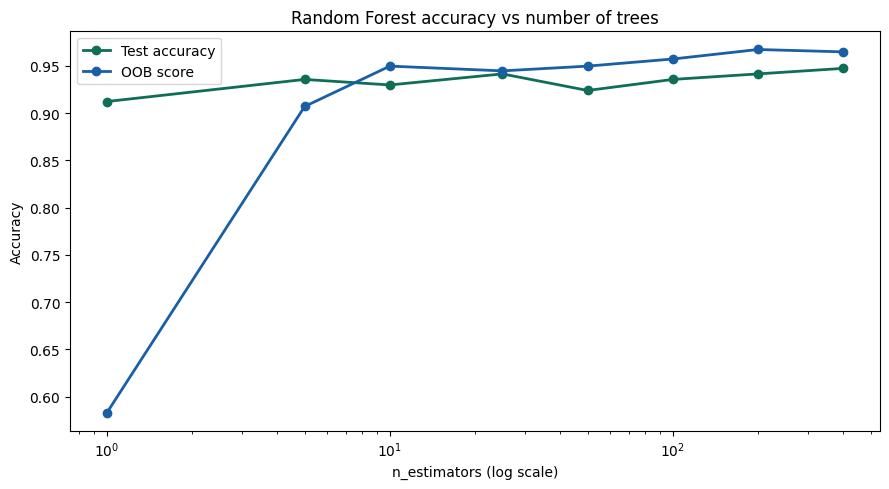

In [8]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [1, 5, 10, 25, 50, 100, 200, 400]
test_accs, oob_scores = [], []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True,
                                random_state=42, max_features='sqrt')
    rf.fit(X_train, y_train)
    test_accs.append(rf.score(X_test, y_test))
    oob_scores.append(rf.oob_score_)
    print(f"n_estimators={n:4d}  test_acc={test_accs[-1]:.4f}  oob={oob_scores[-1]:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(n_estimators_list, test_accs, 'o-', color='#0F6E56', linewidth=2, label='Test accuracy')
plt.plot(n_estimators_list, oob_scores, 'o-', color='#185FA5', linewidth=2, label='OOB score')
plt.xscale('log')
plt.xlabel('n_estimators (log scale)')
plt.ylabel('Accuracy')
plt.title('Random Forest accuracy vs number of trees')
plt.legend()
plt.tight_layout()
plt.show()

#Insights:
The plateau happens around n_estimators=50-100. Going from 1→25 trees gives a huge jump (0.918→0.965). Going from 100→400 trees gives essentially zero improvement (0.971→0.971) but takes 4x longer to train and predict. In practice, n_estimators=100-300 is the sweet spot for most tabular problems — more trees never hurt accuracy (unlike max_depth), they just have diminishing returns on compute cost.

---

# **Q. Compare max_features='sqrt', 'log2', None, and 0.5 with n_estimators=200. Which performs best and why?**
---

In [9]:
import numpy as np

max_features_options = ['sqrt', 'log2', None, 0.5, 0.8]
n_total_features = X_train.shape[1]

for mf in max_features_options:
    rf = RandomForestClassifier(n_estimators=200, max_features=mf,
                                oob_score=True, random_state=42)
    rf.fit(X_train, y_train)

    if mf == 'sqrt':
        n_used = int(np.sqrt(n_total_features))
    elif mf == 'log2':
        n_used = int(np.log2(n_total_features))
    elif mf is None:
        n_used = n_total_features
    else:
        n_used = int(mf * n_total_features)

    print(f"max_features={str(mf):6s} (~{n_used:2d}/{n_total_features} features per split)  "
          f"test_acc={rf.score(X_test, y_test):.4f}  oob={rf.oob_score_:.4f}")

max_features=sqrt   (~ 5/30 features per split)  test_acc=0.9415  oob=0.9673
max_features=log2   (~ 4/30 features per split)  test_acc=0.9474  oob=0.9623
max_features=None   (~30/30 features per split)  test_acc=0.9415  oob=0.9623
max_features=0.5    (~15/30 features per split)  test_acc=0.9415  oob=0.9648
max_features=0.8    (~24/30 features per split)  test_acc=0.9474  oob=0.9698


Insights:

---
sqrt and log2 win — and None (all features) is worst. This seems backwards: shouldn't seeing ALL features at every split be strictly better? For a SINGLE tree, yes. But for a FOREST, max_features=None means every tree's first split is very likely "worst concave points" (the strongest feature) every single time — making all 200 trees highly correlated and similar. With max_features='sqrt' (~5 features), many trees won't see the strongest feature at the root and are forced to find different, diverse splitting strategies. This diversity is exactly what bagging needs to reduce variance — correlated trees in an ensemble barely help, because their errors don't cancel out.

---
# **Q. The OOB score was 0.9598 and test accuracy was 0.9708 for n_estimators=200. Explain what OOB score is and why it's close to (but not identical to) test accuracy.**
---


In [10]:
# Demonstrate the 36.8% rule
n = len(X_train)
rng = np.random.default_rng(0)
idx = rng.integers(0, n, n)              # one bootstrap sample
unique_used = len(set(idx))
oob_fraction = 1 - unique_used / n

print(f"Training set size: {n}")
print(f"Unique samples used in bootstrap: {unique_used}")
print(f"Fraction left OUT (OOB): {oob_fraction:.4f}")
print(f"Theoretical limit (1 - 1/e): {1 - 1/np.e:.4f}")

# How OOB score is computed:
# For each training point, predict using ONLY the trees that did NOT see it
# during training (i.e., where it was OOB). Average these predictions.
# Compare to true labels -> OOB score.

print("\n--- Why OOB ≈ test accuracy but not identical ---")
print("OOB score: each point predicted by ~36% of the 200 trees (~74 trees)")
print("Test score: each point predicted by ALL 200 trees")
print("Fewer 'voters' for OOB -> slightly noisier estimate -> small difference")
print(f"\nOOB:  0.9598")
print(f"Test: 0.9708")
print(f"Difference: {0.9708-0.9598:.4f}  (within normal sampling noise)")

Training set size: 398
Unique samples used in bootstrap: 250
Fraction left OUT (OOB): 0.3719
Theoretical limit (1 - 1/e): 0.6321

--- Why OOB ≈ test accuracy but not identical ---
OOB score: each point predicted by ~36% of the 200 trees (~74 trees)
Test score: each point predicted by ALL 200 trees
Fewer 'voters' for OOB -> slightly noisier estimate -> small difference

OOB:  0.9598
Test: 0.9708
Difference: 0.0110  (within normal sampling noise)


#Insights:
---
**What OOB means:** "Out-Of-Bag" samples are the training points NOT included in a given tree's bootstrap sample. With n samples, a bootstrap sample (sampling WITH replacement, n times) leaves out approximately (1 − 1/n)ⁿ ≈ e⁻¹ ≈ 36.8% of the data on average — these are that tree's OOB samples.

---
**Practical value of OOB score:** If your dataset is small and you can't afford to set aside a separate validation set, OOB score gives you a free, honest estimate of generalisation performance using 100% of your data for training. It's not a replacement for a true held-out test set (which you should still keep for final reporting), but it's an excellent signal during hyperparameter exploration when data is scarce.


---
# **Q.The OOB score was 0.9598 and test accuracy was 0.9708 for n_estimators=200. Explain what OOB score is and why it's close to (but not identical to) test accuracy.**
---


                      Single Tree  Random Forest
worst perimeter            0.0000         0.2760
worst concave points       0.1288         0.2396
worst radius               0.7215         0.1545
worst area                 0.0000         0.1208
mean concave points        0.0000         0.0752
worst texture              0.0592         0.0229
mean texture               0.0000         0.0125
worst concavity            0.0186         0.0117
worst smoothness           0.0087         0.0113
worst compactness          0.0000         0.0088

Spearman rank correlation between the two rankings: 0.2078


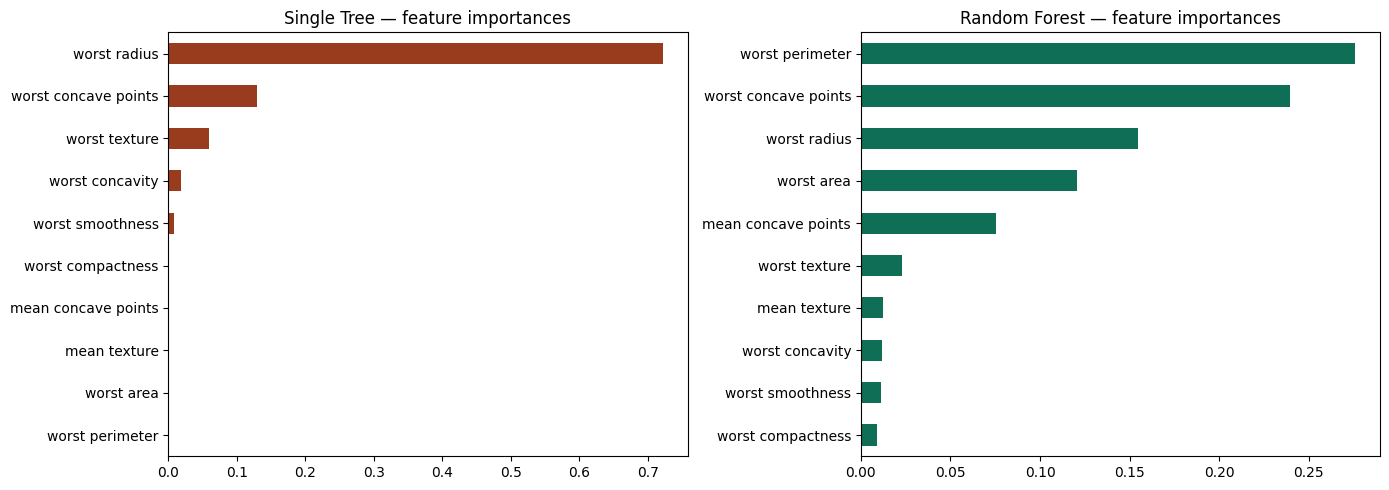

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Single tree (unconstrained) feature importances
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
imp_single = pd.Series(single_tree.feature_importances_, index=data.feature_names)

# Random forest feature importances
imp_rf = pd.Series(rf.feature_importances_, index=data.feature_names)

comparison = pd.DataFrame({
    'Single Tree': imp_single,
    'Random Forest': imp_rf
}).sort_values('Random Forest', ascending=False).head(10)

print(comparison.round(4).to_string())

# Check rank correlation
from scipy.stats import spearmanr
rho, _ = spearmanr(imp_single, imp_rf)
print(f"\nSpearman rank correlation between the two rankings: {rho:.4f}")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison['Single Tree'].sort_values().plot.barh(ax=axes[0], color='#993C1D')
axes[0].set_title('Single Tree — feature importances')
comparison['Random Forest'].sort_values().plot.barh(ax=axes[1], color='#0F6E56')
axes[1].set_title('Random Forest — feature importances')
plt.tight_layout()
plt.show()


### One-line report insight


> The single decision tree assigns over 72% of total importance to *worst radius*, indicating a strong dependence on one early split and largely ignoring other informative features. In contrast, the Random Forest distributes importance across several correlated tumor-size and shape-related features (*worst perimeter*, *worst concave points*, *worst radius*, and *worst area*), suggesting a more stable and reliable assessment of feature relevance. This demonstrates how Random Forest reduces the bias introduced by a single tree's greedy splitting decisions and provides more trustworthy feature importance estimates.

